In [1]:
# Data processing
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import EarlyStopping

from keras import preprocessing as kprocessing
from keras import models, layers, optimizers

import gensim
import gensim.downloader as api

import matplotlib
from matplotlib import pyplot as plt

from datetime import datetime

In [2]:
df = pd.read_csv('tokopedia-cleaned.csv', low_memory=False)
replace_map = {
    1 :'negative',
    2 : 'positive',
    0 : 'neutral'  
}
df['sentiment'] = df['sentiment'].replace(replace_map)
df.rename(columns={"content": "text"}, inplace=True)
df = df[["sentiment", "text"]]
df.head()

,sentiment,text
0,positive,Tokped mantaap
1,negative,kurir pengiriman nya sangat mengecewakan ID ex...
2,negative,Pembatalan belanja status masih proses butuh w...
3,negative,satu fitur yang sangat disayangkan hilang tanp...
4,positive,toped mantab


In [3]:
category_counts = df.groupby('sentiment').size()

# Memfilter kategori yang memiliki lebih dari satu teks
df = df[df['sentiment'].isin(category_counts[category_counts > 1].index)]

print('Total number of news: {}'.format(len(df)))
print(40*'-')
print('Split by sentiment:')

print(df["sentiment"].value_counts())
print(40*'-')
nr_categories = len(df["sentiment"].unique())

print("Number of sentiment: {n}".format(n=nr_categories))

Total number of news: 990
----------------------------------------
Split by sentiment:
sentiment
negative    484
positive    422
neutral      84
Name: count, dtype: int64
----------------------------------------
Number of sentiment: 3


In [4]:
# Renaming, Input -> X, Output -> y
X_tf = df['text']
y_tf_class = df['sentiment']

# Convert labels into a one-hot vector of size 5 (the number of distinct labels)
lab = LabelBinarizer()
lab.fit(y_tf_class)
y_tf = lab.transform(y_tf_class)

# Example (you can modify n)
n=251
print('Coding of labels into a one-hot vector: ' + y_tf_class[n] + ' is ', y_tf[n])

# Split into training and test data
X_tf_train, X_tf_test, y_tf_train, y_tf_test = train_test_split(X_tf, y_tf, test_size=0.3, random_state=42, stratify=df['sentiment'])

Coding of labels into a one-hot vector: positive is  [0 0 1]


In [5]:
corpus = X_tf_train
max_words = 15000
tokenizer = kprocessing.text.Tokenizer(lower=True, split=' ', num_words=max_words, oov_token="<pad>", filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n')
tokenizer.fit_on_texts(corpus)
voc = tokenizer.word_index
reverse_voc = dict([(value, key) for (key, value) in voc.items()])

In [6]:
max_len = 200

sequences = tokenizer.texts_to_sequences(X_tf_train)
X_tf_train_seq = kprocessing.sequence.pad_sequences(sequences, maxlen=max_len)

# Apply the same to test data
X_tf_test_seq = kprocessing.sequence.pad_sequences(tokenizer.texts_to_sequences(X_tf_test), maxlen=max_len)

n=10 # You can adjust n
print('Shape: ',X_tf_train_seq.shape)
print(100*'-')
print('Example: ',X_tf_train_seq[n,:])

Shape:  (693, 200)
----------------------------------------------------------------------------------------------------
Example:  [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 113
   3 872]


In [7]:
# SMOTE membutuhkan data dalam format 2D (tanpa padding)
X_train_smote = X_tf_train_seq.reshape(X_tf_train_seq.shape[0], -1)
y_train_smote = y_tf_train.argmax(axis=1)  # SMOTE bekerja dengan label non-one-hot

# Oversampling dengan SMOTE
smote = SMOTE( random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_smote, y_train_smote)

# Kembalikan hasil resampling ke bentuk asli
X_resampled = X_resampled.reshape(X_resampled.shape[0], max_len)
y_resampled = np.eye(nr_categories)[y_resampled]  # Convert kembali ke one-hot encoding

print("Distribusi setelah SMOTE:")
print(pd.Series(y_resampled.argmax(axis=1)).value_counts())

Distribusi setelah SMOTE:
0    339
2    339
1    339
Name: count, dtype: int64


In [8]:
# This may take several minutes
w2v = api.load("word2vec-google-news-300")
# Example of a word representation:
w2v['iya'].shape

(300,)

In [9]:
# Build weights of the embbeddings matrix using w2v
# emb_matrix=np.zeros((max_words+1, 300))
# for i in range(max_words):
#     w = reverse_voc[i+1]
#     if w in w2v:
#         emb_matrix[i+1,:] = w2v[w]
# emb_size = emb_matrix.shape[1]

# Build weights of the embbeddings matrix using w2v
# emb_matrix=np.zeros((max_words+1, 300))
# for i in range(1,len(reverse_voc)+1):
#     w = reverse_voc.get(i)
#     if w in w2v:
#         emb_matrix[i,:] = w2v[w]
# emb_size = emb_matrix.shape[1]

emb_matrix = np.zeros((max_words+1, 300))
for i in range(max_words):
    if i+1 in reverse_voc:  # Pastikan indeks i+1 ada dalam reverse_voc
        w = reverse_voc[i+1]
        if w in w2v:
            emb_matrix[i+1, :] = w2v[w]
emb_size = emb_matrix.shape[1]

In [43]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import BatchNormalization

input_ = layers.Input(shape = X_tf_train_seq[0,:].shape,name='input')
# Embedding layer (voc size plus un ("UNK", word with index 0)), using the pre-trained emb_matrix obtained from Word2Vec
x = layers.Embedding(max_words+1,emb_size,weights=[emb_matrix],trainable=True, name='embedding')(input_)
# ori dropout 0.2 layer 15
x = layers.Bidirectional(layers.LSTM(20,dropout=0.2),name='bidirectional-lstm')(x) # LSTM layer
# ori 0.2
x = layers.Dropout(0.3, name='dropout_1')(x)
# ori layer 64
x = layers.Dense(64, 
                 activation='relu', 
                 # kernel_regularizer=l2(1e-4), 
                 name='dense')(x)
# x = BatchNormalization(name='batch_norm')(x)
# x = layers.Dropout(0.3, name='dropout_2')(x)
output = layers.Dense(nr_categories, activation='softmax', name='classification')(x)

model = models.Model(input_, output)

# menurunkan learning rate untuk mengurangi loss test ori 0.01
opt = optimizers.Adam(learning_rate=0.0006, beta_1=0.9)
model.compile(optimizer=opt,loss='categorical_crossentropy', metrics=['accuracy'])

In [45]:
class_weights = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(y_tf_train.argmax(axis=1)), 
    y=y_tf_train.argmax(axis=1)
)

# Konversi class weight menjadi dictionary
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: 0.6814159292035398, 1: 3.9152542372881354, 2: 0.7830508474576271}


In [47]:
start_time = datetime.now()
history = model.fit(
    X_tf_train_seq, 
    y_tf_train, 
    batch_size=64, 
    shuffle=True, 
    epochs=12, 
    validation_data=(X_tf_test_seq, y_tf_test),
    # class_weight=class_weights,
)

# early_stopping = EarlyStopping(
#     monitor='val_loss',
#     patience=3,  # Hentikan pelatihan jika val_loss tidak membaik dalam 3 epoch
#     restore_best_weights=True 
# )

# history = model.fit(
#     X_resampled, 
#     y_resampled, 
#     batch_size=64, 
#     shuffle=True, 
#     epochs=10, 
#     validation_data=(X_tf_test_seq, y_tf_test),
#     class_weight=class_weights,
#     # callbacks=[early_stopping]
# )

end_time = datetime.now()

training_time_rnn = (end_time - start_time).total_seconds()

Epoch 1/10
11/11 [==============================] - 10s 494ms/step - loss: 1.1440 - accuracy: 0.4315 - val_loss: 1.0719 - val_accuracy: 0.7138
Epoch 2/10
11/11 [==============================] - 4s 394ms/step - loss: 0.9410 - accuracy: 0.5685 - val_loss: 1.0486 - val_accuracy: 0.7374
Epoch 3/10
11/11 [==============================] - 4s 409ms/step - loss: 0.8307 - accuracy: 0.6407 - val_loss: 1.0335 - val_accuracy: 0.7374
Epoch 4/10
11/11 [==============================] - 5s 430ms/step - loss: 0.7049 - accuracy: 0.6883 - val_loss: 1.0245 - val_accuracy: 0.7508
Epoch 5/10
11/11 [==============================] - 4s 401ms/step - loss: 0.6623 - accuracy: 0.7359 - val_loss: 1.0155 - val_accuracy: 0.7542
Epoch 6/10
11/11 [==============================] - 4s 417ms/step - loss: 0.5786 - accuracy: 0.7633 - val_loss: 1.0017 - val_accuracy: 0.7576
Epoch 7/10
11/11 [==============================] - 5s 417ms/step - loss: 0.4712 - accuracy: 0.8225 - val_loss: 0.9743 - val_accuracy: 0.7879
Epoch

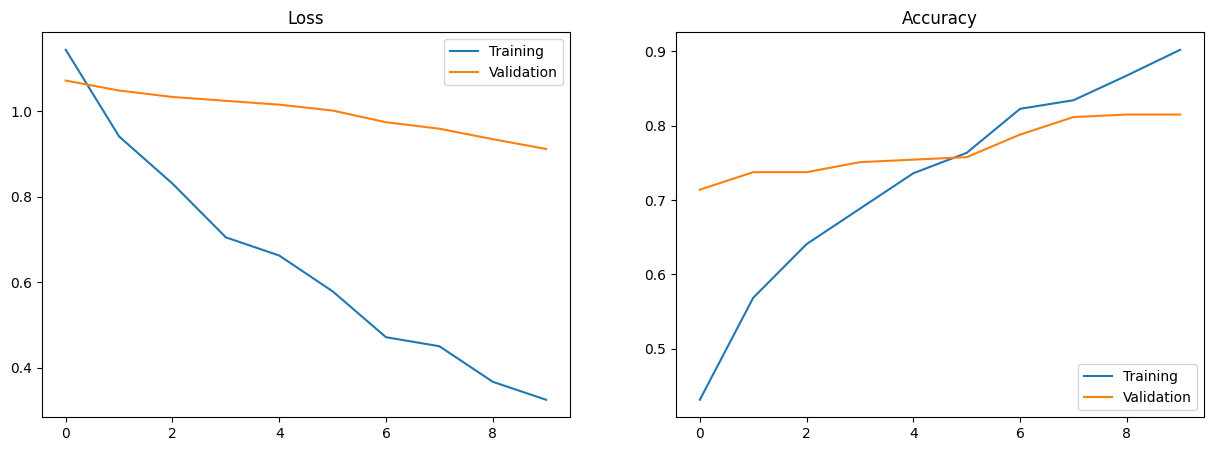

In [53]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
ax[0].set(title='Loss')
ax[0].plot(history.history['loss'], label='Training')
ax[0].plot(history.history['val_loss'], label='Validation')
ax[0].legend(loc="upper right")

ax[1].set(title='Accuracy')
ax[1].plot(history.history['accuracy'], label='Training')
ax[1].plot(history.history['val_accuracy'], label='Validation')
ax[1].legend(loc="lower right")

In [55]:
accuracy_bilstm = history.history['val_accuracy'][-1]
print('Accuracy Training data: {:.1%}'.format(history.history['accuracy'][-1]))
print('Accuracy Test data: {:.1%}'.format(history.history['val_accuracy'][-1]))
print('Training time: {:.1f}s'.format(training_time_rnn))

Accuracy Training data: 90.2%
Accuracy Test data: 81.5%
Training time: 51.0s
